Importamos y cargamos datos 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib

# Precios PVPC reales 2023-2024
pvpc_prices = pd.read_csv("../data/pvpc_prices_2023_2024.csv")
pvpc_prices["datetime"] = pd.to_datetime(pvpc_prices["datetime"], utc=True)
pvpc_prices["datetime"] = pvpc_prices["datetime"].dt.tz_convert("Europe/Madrid")
pvpc_prices["Hour"] = pvpc_prices["datetime"].dt.hour

# Centroides del clustering
centroids_df = pd.read_csv("../data/cluster_centroids.csv")

# Perfiles diarios asignados
daily_profiles = pd.read_csv("../data/daily_cluster_profiles.csv")
daily_profiles["date"] = pd.to_datetime(daily_profiles["date"])

print("Precios PVPC:", pvpc_prices.shape)
print("Centroides:", centroids_df.shape)
print("Perfiles diarios:", daily_profiles.shape)
display(centroids_df[["cluster", "cluster_label"]])

Precios PVPC: (17544, 4)
Centroides: (4, 26)
Perfiles diarios: (1417, 3)


,cluster,cluster_label
0,0,Tarde
1,1,Bajo consumo
2,2,Madrugador
3,3,Alto consumo


Función para clasificar un hogar según su perfil de consumo

In [2]:

def classify_household(hourly_consumption_profile):
    """
    Clasifica un hogar en uno de los 4 perfiles KMeans
    comparando su patrón de consumo horario con los centroides.
    
    hourly_consumption_profile: array o lista de 24 valores (kW por hora)
    Devuelve: cluster_id (int) y cluster_label (str)
    """
    centroid_cols = [f"hour_{h}" for h in range(24)]
    centroids_array = centroids_df[centroid_cols].values
    
    profile = np.array(hourly_consumption_profile).reshape(1, -1)
    
    distances = np.linalg.norm(centroids_array - profile, axis=1)
    
    closest_cluster = np.argmin(distances)
    closest_label = centroids_df.loc[
        centroids_df["cluster"] == closest_cluster, "cluster_label"
    ].values[0]
    
    return {
        "cluster_id": int(closest_cluster),
        "cluster_label": closest_label,
        "distances": {
            centroids_df.loc[i, "cluster_label"]: round(distances[i], 4)
            for i in range(len(distances))
        }
    }

print("Función classify_household definida correctamente.")

Función classify_household definida correctamente.


Test de clasificación con perfiles reales del UCI

In [3]:
# Cargar consumo horario UCI
hourly_consumption_df = pd.read_csv("../data/hourly_consumption.csv")
avg_profile = hourly_consumption_df["avg_consumption_kwh"].values

print("=== Test con perfil medio UCI ===")
result = classify_household(avg_profile)
print(f"Perfil asignado: {result['cluster_label']} (Cluster {result['cluster_id']})")
print(f"Distancias a cada centroide:")
for label, dist in result["distances"].items():
    print(f"  {label}: {dist}")

=== Test con perfil medio UCI ===
Perfil asignado: Madrugador (Cluster 2)
Distancias a cada centroide:
  Tarde: 2.6626
  Bajo consumo: 2.4426
  Madrugador: 1.0712
  Alto consumo: 4.0561


Catálogo de dispositivos con restricciones horarias

In [4]:
devices_catalog = [
    {
        "device_name": "Lavadora",
        "energy_kwh": 1.0,
        "allowed_start_hour": 7,
        "allowed_end_hour": 23
    },
    {
        "device_name": "Lavavajillas",
        "energy_kwh": 1.3,
        "allowed_start_hour": 8,
        "allowed_end_hour": 23
    },
    {
        "device_name": "Secadora",
        "energy_kwh": 2.0,
        "allowed_start_hour": 9,
        "allowed_end_hour": 22
    },
    {
        "device_name": "Termo eléctrico",
        "energy_kwh": 2.5,
        "allowed_start_hour": 0,
        "allowed_end_hour": 23
    }
]

Función de penalización por perfil

In [5]:
def get_profile_penalty(cluster_id, alpha=0.5):
    """
    Calcula un factor de penalización por hora basado en el perfil del hogar.
    
    cluster_id: identificador del cluster (0-3)
    alpha: peso de la penalización (0 = sin penalización, 1 = penalización máxima)
    
    Devuelve: array de 24 valores, uno por hora,
              donde valores altos indican horas a evitar por consumo propio
    """
    centroid_cols = [f"hour_{h}" for h in range(24)]
    centroid = centroids_df.loc[
        centroids_df["cluster"] == cluster_id, centroid_cols
    ].values[0]
    
    # Normalizar entre 0 y 1
    min_val = centroid.min()
    max_val = centroid.max()
    normalized = (centroid - min_val) / (max_val - min_val)
    
    # Factor de penalización: horas de alto consumo propio tienen valor alto
    penalty = 1 + alpha * normalized
    
    return penalty

# Verificar
for i in range(4):
    label = centroids_df.loc[centroids_df["cluster"] == i, "cluster_label"].values[0]
    penalty = get_profile_penalty(i)
    hora_mas_penalizada = np.argmax(penalty)
    hora_menos_penalizada = np.argmin(penalty)
    print(f"{label} — Hora más penalizada: {hora_mas_penalizada}:00 | "
          f"Hora menos penalizada: {hora_menos_penalizada}:00")

Tarde — Hora más penalizada: 19:00 | Hora menos penalizada: 4:00
Bajo consumo — Hora más penalizada: 21:00 | Hora menos penalizada: 3:00
Madrugador — Hora más penalizada: 20:00 | Hora menos penalizada: 3:00
Alto consumo — Hora más penalizada: 20:00 | Hora menos penalizada: 23:00


Función recomendador v2 con perfil integrado

In [6]:
def recommend_device_v2(
    prices_df,
    device_name,
    energy_kwh,
    date,
    cluster_id,
    allowed_start_hour=0,
    allowed_end_hour=23,
    alpha=0.5,
    top_n=5
):
    """
    Recomienda las mejores horas para usar un dispositivo combinando:
    - Precio PVPC real de la hora
    - Penalización por perfil de consumo del hogar
    
    El coste ajustado = precio_real * penalización_perfil * energía_kwh
    """
    # Filtrar precios del día
    day_prices = prices_df[
        prices_df["datetime"].dt.date == pd.to_datetime(date).date()
    ].copy()

    day_prices = day_prices[
        (day_prices["Hour"] >= allowed_start_hour) &
        (day_prices["Hour"] <= allowed_end_hour)
    ].copy()

    # Obtener penalización del perfil
    penalty = get_profile_penalty(cluster_id, alpha=alpha)

    # Aplicar penalización por hora
    day_prices["penalty"] = day_prices["Hour"].apply(lambda h: penalty[h])

    # Coste real sin penalización
    day_prices["device_cost_eur"] = (
        day_prices["price_eur_kwh"] * energy_kwh
    )

    # Coste ajustado con perfil
    day_prices["adjusted_cost"] = (
        day_prices["price_eur_kwh"] * day_prices["penalty"] * energy_kwh
    )

    day_prices["device"] = device_name

    recommendations = day_prices.sort_values("adjusted_cost").head(top_n)

    return recommendations[[
        "device", "datetime", "Hour",
        "price_eur_kwh", "penalty",
        "device_cost_eur", "adjusted_cost"
    ]]

 Test del recomendador v2

In [7]:
date_test = "2023-06-15"

print("=== Perfil Madrugador ===")
display(recommend_device_v2(
    prices_df=pvpc_prices,
    device_name="Lavadora",
    energy_kwh=1.0,
    date=date_test,
    cluster_id=2,  # Madrugador
    allowed_start_hour=7,
    allowed_end_hour=23,
    top_n=5
))

print("\n=== Perfil Tarde ===")
display(recommend_device_v2(
    prices_df=pvpc_prices,
    device_name="Lavadora",
    energy_kwh=1.0,
    date=date_test,
    cluster_id=0,  # Tarde
    allowed_start_hour=7,
    allowed_end_hour=23,
    top_n=5
))

=== Perfil Madrugador ===


,device,datetime,Hour,price_eur_kwh,penalty,device_cost_eur,adjusted_cost
3974,Lavadora,2023-06-15 15:00:00+02:00,15,0.15269,1.094687,0.15269,0.167148
3973,Lavadora,2023-06-15 14:00:00+02:00,14,0.14935,1.129387,0.14935,0.168674
3975,Lavadora,2023-06-15 16:00:00+02:00,16,0.15613,1.087825,0.15613,0.169842
3976,Lavadora,2023-06-15 17:00:00+02:00,17,0.15975,1.117963,0.15975,0.178595
3982,Lavadora,2023-06-15 23:00:00+02:00,23,0.18186,1.115117,0.18186,0.202795



=== Perfil Tarde ===


,device,datetime,Hour,price_eur_kwh,penalty,device_cost_eur,adjusted_cost
3966,Lavadora,2023-06-15 07:00:00+02:00,7,0.14542,1.200669,0.14542,0.174601
3973,Lavadora,2023-06-15 14:00:00+02:00,14,0.14935,1.366365,0.14935,0.204067
3974,Lavadora,2023-06-15 15:00:00+02:00,15,0.15269,1.340716,0.15269,0.204714
3975,Lavadora,2023-06-15 16:00:00+02:00,16,0.15613,1.314280,0.15613,0.205199
3968,Lavadora,2023-06-15 09:00:00+02:00,9,0.16763,1.250979,0.16763,0.209702


Función planificación v2 sin solape con perfil

In [8]:
def schedule_devices_v2(
    prices_df,
    devices,
    date,
    cluster_id,
    alpha=0.5
):
    """
    Planifica varios dispositivos sin solape usando el coste ajustado
    por perfil de hogar.
    """
    scheduled_results = []
    occupied_hours = set()
    
    cluster_label = centroids_df.loc[
        centroids_df["cluster"] == cluster_id, "cluster_label"
    ].values[0]

    for device in devices:
        day_prices = prices_df[
            prices_df["datetime"].dt.date == pd.to_datetime(date).date()
        ].copy()

        day_prices = day_prices[
            (day_prices["Hour"] >= device["allowed_start_hour"]) &
            (day_prices["Hour"] <= device["allowed_end_hour"])
        ].copy()

        free_hours = day_prices[
            ~day_prices["Hour"].isin(occupied_hours)
        ].copy()

        if free_hours.empty:
            free_hours = day_prices.copy()

        penalty = get_profile_penalty(cluster_id, alpha=alpha)
        free_hours["penalty"] = free_hours["Hour"].apply(lambda h: penalty[h])
        free_hours["adjusted_cost"] = (
            free_hours["price_eur_kwh"] * free_hours["penalty"] * device["energy_kwh"]
        )
        free_hours["device_cost_eur"] = (
            free_hours["price_eur_kwh"] * device["energy_kwh"]
        )

        best = free_hours.sort_values("adjusted_cost").iloc[0]
        occupied_hours.add(int(best["Hour"]))

        scheduled_results.append({
            "device": device["device_name"],
            "cluster_label": cluster_label,
            "recommended_hour": int(best["Hour"]),
            "price_eur_kwh": round(best["price_eur_kwh"], 4),
            "penalty": round(best["penalty"], 4),
            "energy_kwh": device["energy_kwh"],
            "device_cost_eur": round(best["device_cost_eur"], 4),
            "adjusted_cost": round(best["adjusted_cost"], 4)
        })

    return pd.DataFrame(scheduled_results)

 Test planificación v2 comparando dos perfiles

In [9]:
date_test = "2023-06-15"

print("=== Planificación para perfil Madrugador ===")
display(schedule_devices_v2(
    prices_df=pvpc_prices,
    devices=devices_catalog,
    date=date_test,
    cluster_id=2
))

print("\n=== Planificación para perfil Tarde ===")
display(schedule_devices_v2(
    prices_df=pvpc_prices,
    devices=devices_catalog,
    date=date_test,
    cluster_id=0
))

=== Planificación para perfil Madrugador ===


,device,cluster_label,recommended_hour,price_eur_kwh,penalty,energy_kwh,device_cost_eur,adjusted_cost
0,Lavadora,Madrugador,15,0.1527,1.0947,1.0,0.1527,0.1671
1,Lavavajillas,Madrugador,14,0.1493,1.1294,1.3,0.1942,0.2193
2,Secadora,Madrugador,16,0.1561,1.0878,2.0,0.3123,0.3397
3,Termo eléctrico,Madrugador,5,0.1361,1.0077,2.5,0.3402,0.3428



=== Planificación para perfil Tarde ===


,device,cluster_label,recommended_hour,price_eur_kwh,penalty,energy_kwh,device_cost_eur,adjusted_cost
0,Lavadora,Tarde,7,0.1454,1.2007,1.0,0.1454,0.1746
1,Lavavajillas,Tarde,14,0.1493,1.3664,1.3,0.1942,0.2653
2,Secadora,Tarde,15,0.1527,1.3407,2.0,0.3054,0.4094
3,Termo eléctrico,Tarde,5,0.1361,1.0014,2.5,0.3402,0.3407


Función baseline v2

In [10]:
def baseline_device_costs_v2(
    prices_df,
    devices,
    date,
    cluster_id,
    baseline_hour=20
):
    """
    Calcula el coste baseline usando el precio real a la hora fija,
    sin optimización ni perfil.
    """
    day_prices = prices_df[
        prices_df["datetime"].dt.date == pd.to_datetime(date).date()
    ].copy()

    baseline_price = day_prices[
        day_prices["Hour"] == baseline_hour
    ]["price_eur_kwh"].iloc[0]

    cluster_label = centroids_df.loc[
        centroids_df["cluster"] == cluster_id, "cluster_label"
    ].values[0]

    results = []
    for device in devices:
        cost = baseline_price * device["energy_kwh"]
        results.append({
            "device": device["device_name"],
            "cluster_label": cluster_label,
            "baseline_hour": baseline_hour,
            "baseline_price_eur_kwh": round(baseline_price, 4),
            "energy_kwh": device["energy_kwh"],
            "baseline_cost_eur": round(cost, 4)
        })

    return pd.DataFrame(results)

Función comparación v2

In [11]:
def compare_v2_vs_baseline(
    prices_df,
    devices,
    date,
    cluster_id,
    alpha=0.5,
    baseline_hour=20
):
    """
    Compara el coste optimizado con perfil vs el escenario no optimizado.
    """
    schedule = schedule_devices_v2(
        prices_df=prices_df,
        devices=devices,
        date=date,
        cluster_id=cluster_id,
        alpha=alpha
    )

    baseline = baseline_device_costs_v2(
        prices_df=prices_df,
        devices=devices,
        date=date,
        cluster_id=cluster_id,
        baseline_hour=baseline_hour
    )

    comparison = pd.merge(
        baseline,
        schedule,
        on=["device", "cluster_label", "energy_kwh"]
    )

    comparison["savings_eur"] = (
        comparison["baseline_cost_eur"] - comparison["device_cost_eur"]
    )
    comparison["savings_pct"] = (
        comparison["savings_eur"] / comparison["baseline_cost_eur"]
    ) * 100

    return comparison

Test comparación v2 para los 4 perfiles

In [12]:
date_test = "2023-06-15"

for cluster_id in range(4):
    label = centroids_df.loc[
        centroids_df["cluster"] == cluster_id, "cluster_label"
    ].values[0]
    
    comp = compare_v2_vs_baseline(
        prices_df=pvpc_prices,
        devices=devices_catalog,
        date=date_test,
        cluster_id=cluster_id
    )
    
    total_baseline = comp["baseline_cost_eur"].sum()
    total_optimized = comp["device_cost_eur"].sum()
    total_savings = comp["savings_eur"].sum()
    total_pct = round((total_savings / total_baseline) * 100, 2)
    
    print(f"Perfil {label}:")
    print(f"  Baseline: {round(total_baseline, 4)} € | "
          f"Optimizado: {round(total_optimized, 4)} € | "
          f"Ahorro: {round(total_savings, 4)} € ({total_pct}%)")
    print()

Perfil Tarde:
  Baseline: 1.4745 € | Optimizado: 0.9852 € | Ahorro: 0.4893 € (33.18%)

Perfil Bajo consumo:
  Baseline: 1.4745 € | Optimizado: 1.0003 € | Ahorro: 0.4742 € (32.16%)

Perfil Madrugador:
  Baseline: 1.4745 € | Optimizado: 0.9994 € | Ahorro: 0.4751 € (32.22%)

Perfil Alto consumo:
  Baseline: 1.4745 € | Optimizado: 0.9946 € | Ahorro: 0.4799 € (32.55%)



Evaluación multi-día por perfil

In [13]:
def evaluate_multiday_v2(
    prices_df,
    devices,
    dates,
    cluster_id,
    alpha=0.5,
    baseline_hour=20
):
    """
    Evalúa el sistema v2 sobre múltiples días para un perfil dado.
    """
    all_results = []

    for date in dates:
        try:
            comp = compare_v2_vs_baseline(
                prices_df=prices_df,
                devices=devices,
                date=date,
                cluster_id=cluster_id,
                alpha=alpha,
                baseline_hour=baseline_hour
            )
            comp["date"] = date
            all_results.append(comp)
        except Exception:
            continue

    return pd.concat(all_results, ignore_index=True)

Ejecución evaluación multi-día para los 4 perfiles

In [14]:
available_dates = (
    pvpc_prices["datetime"]
    .dt.date
    .astype(str)
    .unique()
)

sample_dates = available_dates[:30]

summary_by_profile = []

for cluster_id in range(4):
    label = centroids_df.loc[
        centroids_df["cluster"] == cluster_id, "cluster_label"
    ].values[0]

    results = evaluate_multiday_v2(
        prices_df=pvpc_prices,
        devices=devices_catalog,
        dates=sample_dates,
        cluster_id=cluster_id
    )

    daily = (
        results.groupby("date")
        .agg(
            baseline_total=("baseline_cost_eur", "sum"),
            optimized_total=("device_cost_eur", "sum"),
            savings_total=("savings_eur", "sum")
        )
        .reset_index()
    )

    daily["savings_pct"] = (
        daily["savings_total"] / daily["baseline_total"]
    ) * 100

    summary_by_profile.append({
        "cluster_id": cluster_id,
        "cluster_label": label,
        "avg_baseline_eur": round(daily["baseline_total"].mean(), 4),
        "avg_optimized_eur": round(daily["optimized_total"].mean(), 4),
        "avg_savings_eur": round(daily["savings_total"].mean(), 4),
        "avg_savings_pct": round(daily["savings_pct"].mean(), 2)
    })

summary_df = pd.DataFrame(summary_by_profile)
display(summary_df)

,cluster_id,cluster_label,avg_baseline_eur,avg_optimized_eur,avg_savings_eur,avg_savings_pct
0,0,Tarde,1.4342,0.6351,0.7990,54.01
1,1,Bajo consumo,1.4342,0.6413,0.7929,53.93
2,2,Madrugador,1.4342,0.6408,0.7934,53.94
3,3,Alto consumo,1.4342,0.6431,0.7911,53.64


Gráfica comparativa de ahorro por perfil


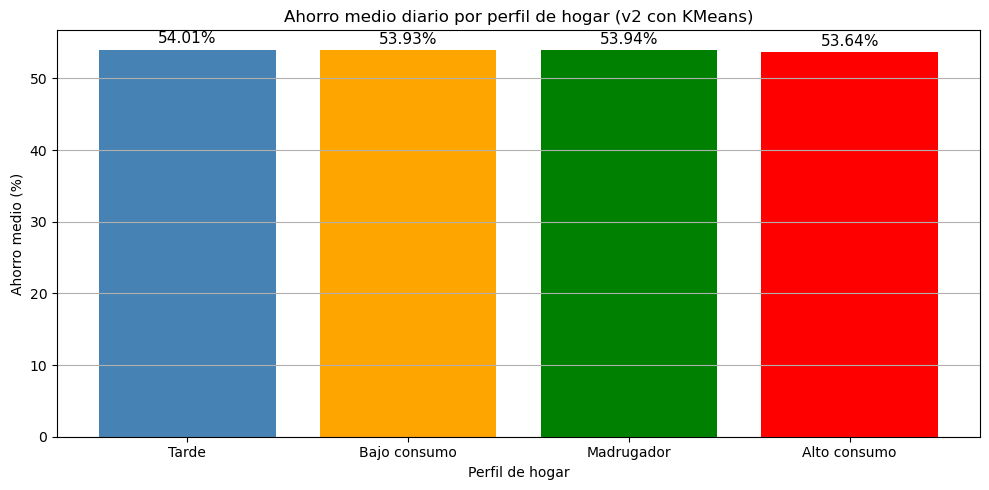

In [15]:
plt.figure(figsize=(10, 5))
colors = ["steelblue", "orange", "green", "red"]

bars = plt.bar(
    summary_df["cluster_label"],
    summary_df["avg_savings_pct"],
    color=colors
)

for bar, val in zip(bars, summary_df["avg_savings_pct"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val}%",
        ha="center", va="bottom", fontsize=11
    )

plt.title("Ahorro medio diario por perfil de hogar (v2 con KMeans)")
plt.xlabel("Perfil de hogar")
plt.ylabel("Ahorro medio (%)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Guardamos los resultados

In [16]:
summary_df.to_csv(
    "../data/summary_by_profile_v2.csv",
    index=False
)

print("Archivo guardado: summary_by_profile_v2.csv")
print("\n=== Resumen final sistema v2 ===")
print(f"Días evaluados: {len(sample_dates)}")
print(f"Perfiles analizados: {len(summary_df)}")
print(f"Ahorro medio global: "
      f"{round(summary_df['avg_savings_pct'].mean(), 2)}%")

Archivo guardado: summary_by_profile_v2.csv

=== Resumen final sistema v2 ===
Días evaluados: 30
Perfiles analizados: 4
Ahorro medio global: 53.88%


Alpha=0,5 es demasiado bajamos así que probamos con un alpha mas alto.

In [17]:
alphas = [0.5, 1.0, 2.0, 3.0, 5.0]
date_test = "2023-06-15"

print("Horas recomendadas para Lavadora según alpha:\n")
print(f"{'Alpha':<8} {'Madrugador':<15} {'Tarde':<15} {'Distintas?'}")
print("-" * 45)

for alpha in alphas:
    rec_madrugador = recommend_device_v2(
        prices_df=pvpc_prices,
        device_name="Lavadora",
        energy_kwh=1.0,
        date=date_test,
        cluster_id=2,
        allowed_start_hour=7,
        allowed_end_hour=23,
        alpha=alpha,
        top_n=1
    )["Hour"].values[0]

    rec_tarde = recommend_device_v2(
        prices_df=pvpc_prices,
        device_name="Lavadora",
        energy_kwh=1.0,
        date=date_test,
        cluster_id=0,
        allowed_start_hour=7,
        allowed_end_hour=23,
        alpha=alpha,
        top_n=1
    )["Hour"].values[0]

    distintas = "✓ SÍ" if rec_madrugador != rec_tarde else "✗ NO"
    print(f"{alpha:<8} {rec_madrugador}:00{'':<12} {rec_tarde}:00{'':<12} {distintas}")

Horas recomendadas para Lavadora según alpha:

Alpha    Madrugador      Tarde           Distintas?
---------------------------------------------
0.5      15:00             7:00             ✓ SÍ
1.0      15:00             7:00             ✓ SÍ
2.0      15:00             7:00             ✓ SÍ
3.0      16:00             7:00             ✓ SÍ
5.0      16:00             7:00             ✓ SÍ


Lo re-evaluamos con alpha óptimo 2

In [18]:
ALPHA_OPTIMO = 2.0

summary_by_profile_v2 = []

for cluster_id in range(4):
    label = centroids_df.loc[
        centroids_df["cluster"] == cluster_id, "cluster_label"
    ].values[0]

    results = evaluate_multiday_v2(
        prices_df=pvpc_prices,
        devices=devices_catalog,
        dates=sample_dates,
        cluster_id=cluster_id,
        alpha=ALPHA_OPTIMO
    )

    daily = (
        results.groupby("date")
        .agg(
            baseline_total=("baseline_cost_eur", "sum"),
            optimized_total=("device_cost_eur", "sum"),
            savings_total=("savings_eur", "sum")
        )
        .reset_index()
    )

    daily["savings_pct"] = (
        daily["savings_total"] / daily["baseline_total"]
    ) * 100

    summary_by_profile_v2.append({
        "cluster_id": cluster_id,
        "cluster_label": label,
        "avg_baseline_eur": round(daily["baseline_total"].mean(), 4),
        "avg_optimized_eur": round(daily["optimized_total"].mean(), 4),
        "avg_savings_eur": round(daily["savings_total"].mean(), 4),
        "avg_savings_pct": round(daily["savings_pct"].mean(), 2)
    })

summary_df_v2 = pd.DataFrame(summary_by_profile_v2)
display(summary_df_v2)

,cluster_id,cluster_label,avg_baseline_eur,avg_optimized_eur,avg_savings_eur,avg_savings_pct
0,0,Tarde,1.4342,0.6549,0.7793,52.16
1,1,Bajo consumo,1.4342,0.6540,0.7802,52.70
2,2,Madrugador,1.4342,0.6506,0.7836,52.79
3,3,Alto consumo,1.4342,0.6656,0.7686,51.80


Gráfica comparativa con alpha óptimo

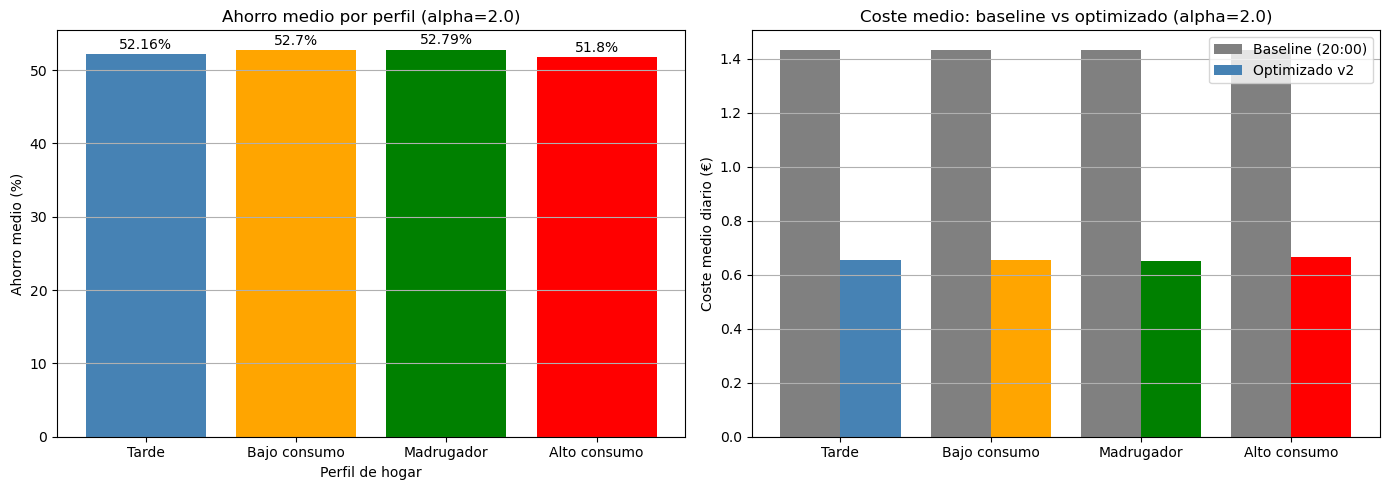

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["steelblue", "orange", "green", "red"]

# Ahorro medio por perfil
bars = axes[0].bar(
    summary_df_v2["cluster_label"],
    summary_df_v2["avg_savings_pct"],
    color=colors
)
for bar, val in zip(bars, summary_df_v2["avg_savings_pct"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val}%",
        ha="center", va="bottom", fontsize=10
    )
axes[0].set_title(f"Ahorro medio por perfil (alpha={ALPHA_OPTIMO})")
axes[0].set_xlabel("Perfil de hogar")
axes[0].set_ylabel("Ahorro medio (%)")
axes[0].grid(axis="y")

# Coste medio optimizado vs baseline
x = range(len(summary_df_v2))
axes[1].bar(
    [i - 0.2 for i in x],
    summary_df_v2["avg_baseline_eur"],
    width=0.4,
    label="Baseline (20:00)",
    color="gray"
)
axes[1].bar(
    [i + 0.2 for i in x],
    summary_df_v2["avg_optimized_eur"],
    width=0.4,
    label="Optimizado v2",
    color=colors
)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(summary_df_v2["cluster_label"])
axes[1].set_title(f"Coste medio: baseline vs optimizado (alpha={ALPHA_OPTIMO})")
axes[1].set_ylabel("Coste medio diario (€)")
axes[1].legend()
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

Volvemos a guardar

In [20]:
summary_df_v2.to_csv(
    "../data/summary_by_profile_v2.csv",
    index=False
)

print("Archivo guardado: summary_by_profile_v2.csv")
print("\n=== Resumen final sistema v2 ===")
print(f"Días evaluados: {len(sample_dates)}")
print(f"Alpha utilizado: {ALPHA_OPTIMO}")
print(f"Perfiles analizados: {len(summary_df_v2)}")
print(f"Ahorro medio global: "
      f"{round(summary_df_v2['avg_savings_pct'].mean(), 2)}%")
print(f"Ahorro medio en euros: "
      f"{round(summary_df_v2['avg_savings_eur'].mean(), 4)} €/día")
print(f"Ahorro anual estimado: "
      f"{round(summary_df_v2['avg_savings_eur'].mean() * 365, 2)} €/año")

Archivo guardado: summary_by_profile_v2.csv

=== Resumen final sistema v2 ===
Días evaluados: 30
Alpha utilizado: 2.0
Perfiles analizados: 4
Ahorro medio global: 52.36%
Ahorro medio en euros: 0.7779 €/día
Ahorro anual estimado: 283.94 €/año
